## Path configuration

In [2]:
from pathlib import Path
import os
import sys

PROJECT_NAME = "MALDIAlign"
cwd = Path().resolve()

target = None
for parent in [cwd] + list(cwd.parents):
    if parent.name == PROJECT_NAME:
        target = parent
        break

if target is not None and target != cwd:
    os.chdir(target)
    sys.path.append(str(target))

## Imports

In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

/export/usuarios01/agnavarr/MALDIAlign/.venv/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Load data

In [89]:
OUTPUT_DIR = Path("/export/usuarios01/agnavarr/MALDIAlign/experiments/novelty_detection/results/20260622_092158")

SWEEP_PERCENTILES = [0.01, 0.05, 0.1, 0.5, 1]
# SWEEP_PERCENTILES = [0.1, 0.05]


############################################################
# LEER Y UNIR TODOS LOS CSV POR PERCENTIL
############################################################
all_rows = []
for p in SWEEP_PERCENTILES:
    fname = OUTPUT_DIR / f"novelty_detection_per_species_p{str(p).replace('.','')}.csv"
    df_p = pd.read_csv(fname)
    df_p["percentile"] = p
    all_rows.append(df_p)

df_all = pd.concat(all_rows, ignore_index=True)

## GMM Plots

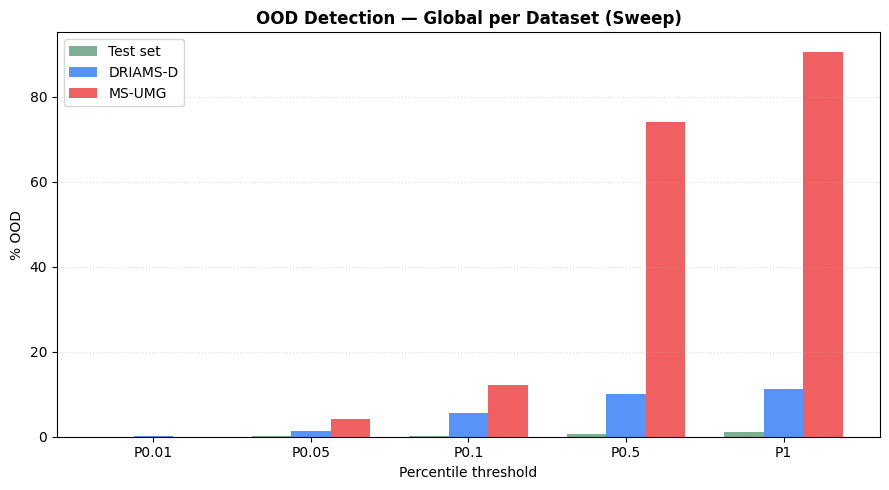

In [91]:
############################################################
# PLOT 1 — OOD GLOBAL POR DATASET (sweep) — BARPLOT
############################################################
fig, ax = plt.subplots(figsize=(9, 5))

datasets = [("test", "#66A182", "Test set"), ("driams_d", "#3B82F6", "DRIAMS-D"), ("msumg", "#EF4444", "MS-UMG")]
x = np.arange(len(SWEEP_PERCENTILES))
width = 0.25

for i, (name, color, label) in enumerate(datasets):
    global_pct = []
    for p in SWEEP_PERCENTILES:
        sub = df_all[df_all["percentile"] == p]
        n_total = sub[f"{name}_n"].sum()
        weighted_ood = (sub[f"{name}_n"] * sub[f"{name}_pct_ood"]).sum() / n_total
        global_pct.append(weighted_ood)
    ax.bar(x + i * width, global_pct, width, color=color, label=label, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels([f"P{p}" for p in SWEEP_PERCENTILES])
ax.set_xlabel("Percentile threshold")
ax.set_ylabel("% OOD")
ax.set_title("OOD Detection — Global per Dataset (Sweep)", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(True, axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

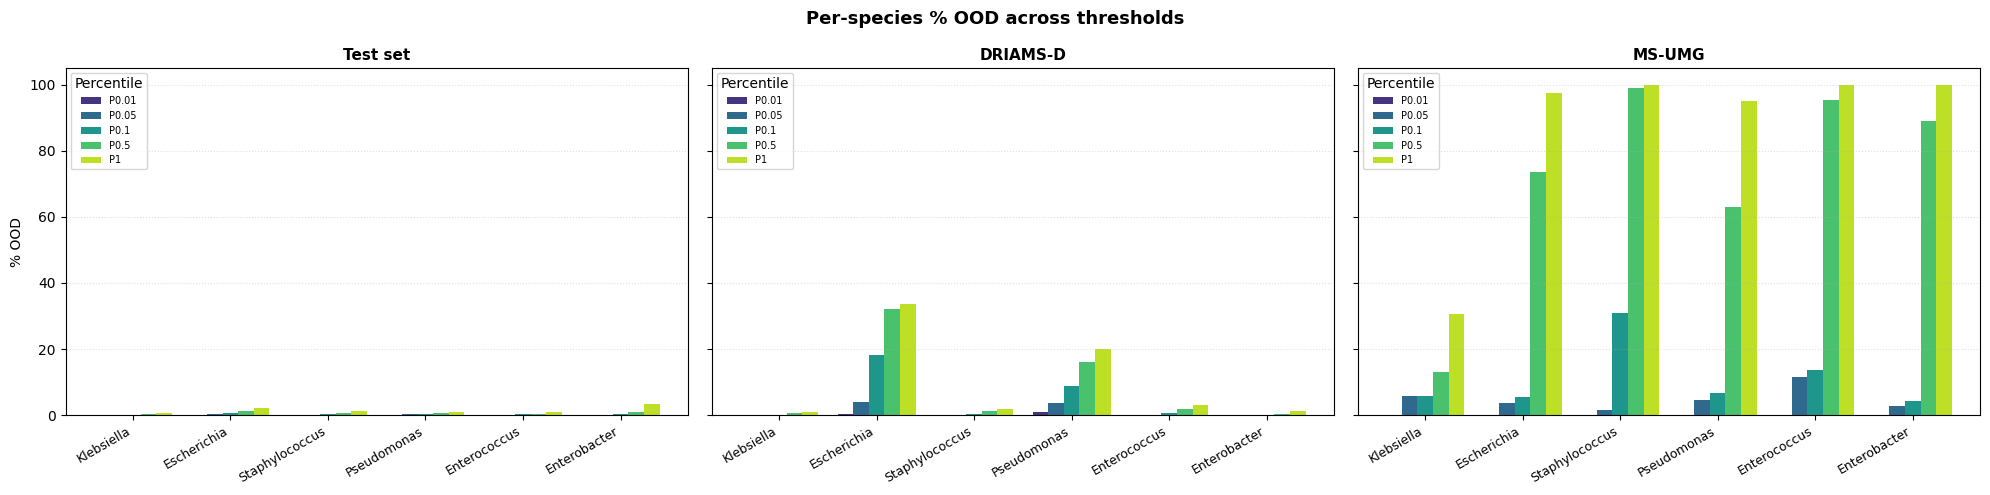

In [92]:
############################################################
# PLOT 2 — PER-SPECIES % OOD — BARPLOT
############################################################
species_list = df_all["species"].unique()
species_short = [s.split("_")[0] for s in species_list]

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

colors_pct = plt.cm.viridis(np.linspace(0.15, 0.9, len(SWEEP_PERCENTILES)))

for ax, name, ds_label in zip(axes, ["test", "driams_d", "msumg"], ["Test set", "DRIAMS-D", "MS-UMG"]):
    x = np.arange(len(species_list))
    width = 0.8 / len(SWEEP_PERCENTILES)

    for i, p in enumerate(SWEEP_PERCENTILES):
        sub = df_all[df_all["percentile"] == p].set_index("species").loc[species_list]
        vals = sub[f"{name}_pct_ood"].values
        ax.bar(x + i * width, vals, width, color=colors_pct[i], label=f"P{p}")

    ax.set_xticks(x + width * (len(SWEEP_PERCENTILES) - 1) / 2)
    ax.set_xticklabels(species_short, rotation=30, ha="right", fontsize=9)
    ax.set_title(ds_label, fontsize=11, fontweight="bold")
    ax.grid(True, axis="y", linestyle=":", alpha=0.4)
    ax.set_ylim(0, 105)
    ax.legend(title="Percentile", fontsize=7, loc="upper left")

axes[0].set_ylabel("% OOD")
fig.suptitle("Per-species % OOD across thresholds", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

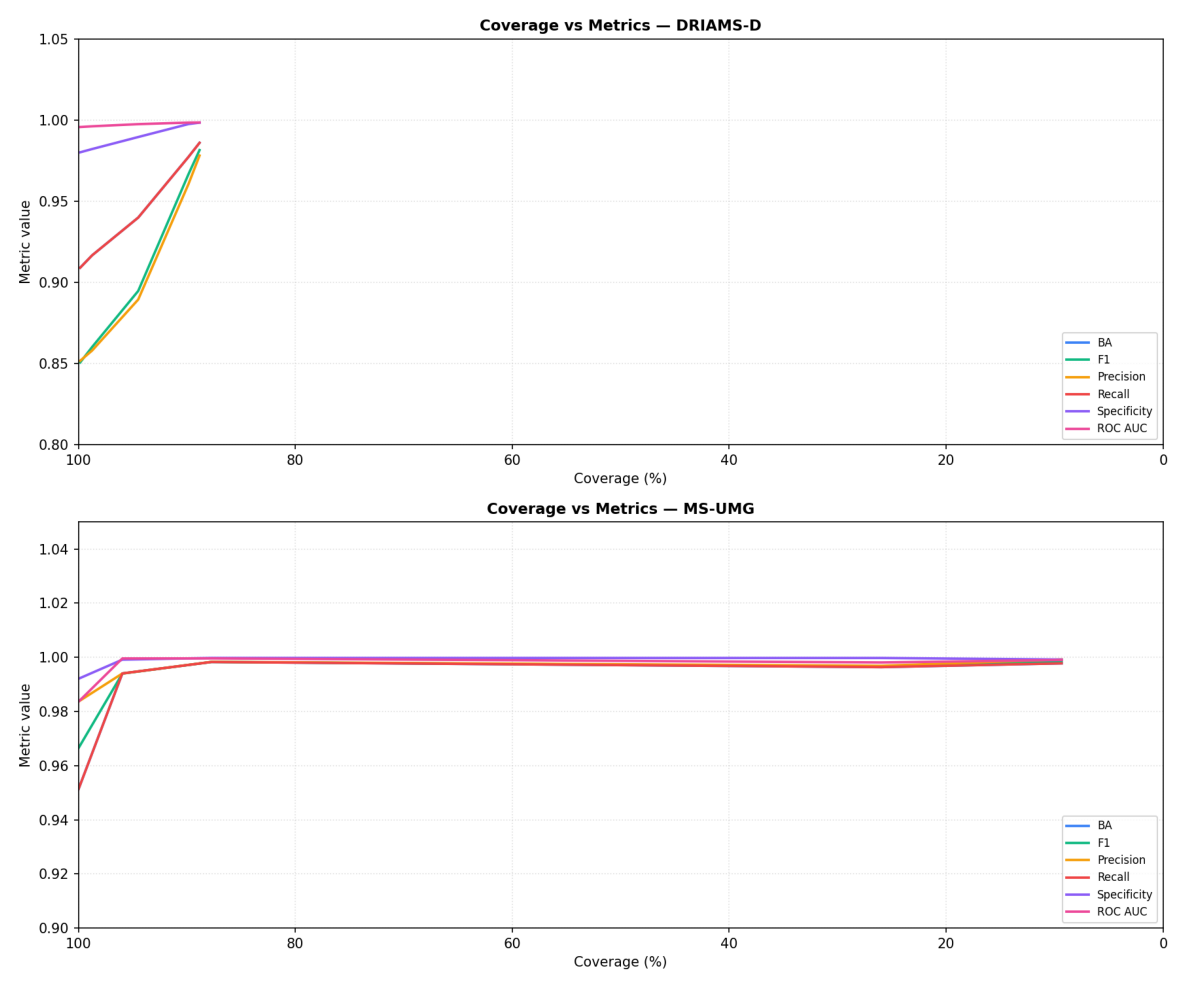

In [68]:
############################################################
# PLOT 3 - COVERAGE
############################################################
img_path = "/export/usuarios01/agnavarr/MALDIAlign/experiments/novelty_detection/results/20260622_092158/coverage_vs_metrics.png"
img = mpimg.imread(img_path)
plt.figure(figsize=(15, 10))
plt.imshow(img)
plt.axis("off")
plt.tight_layout()
plt.show()

Especies con n>=10: 336


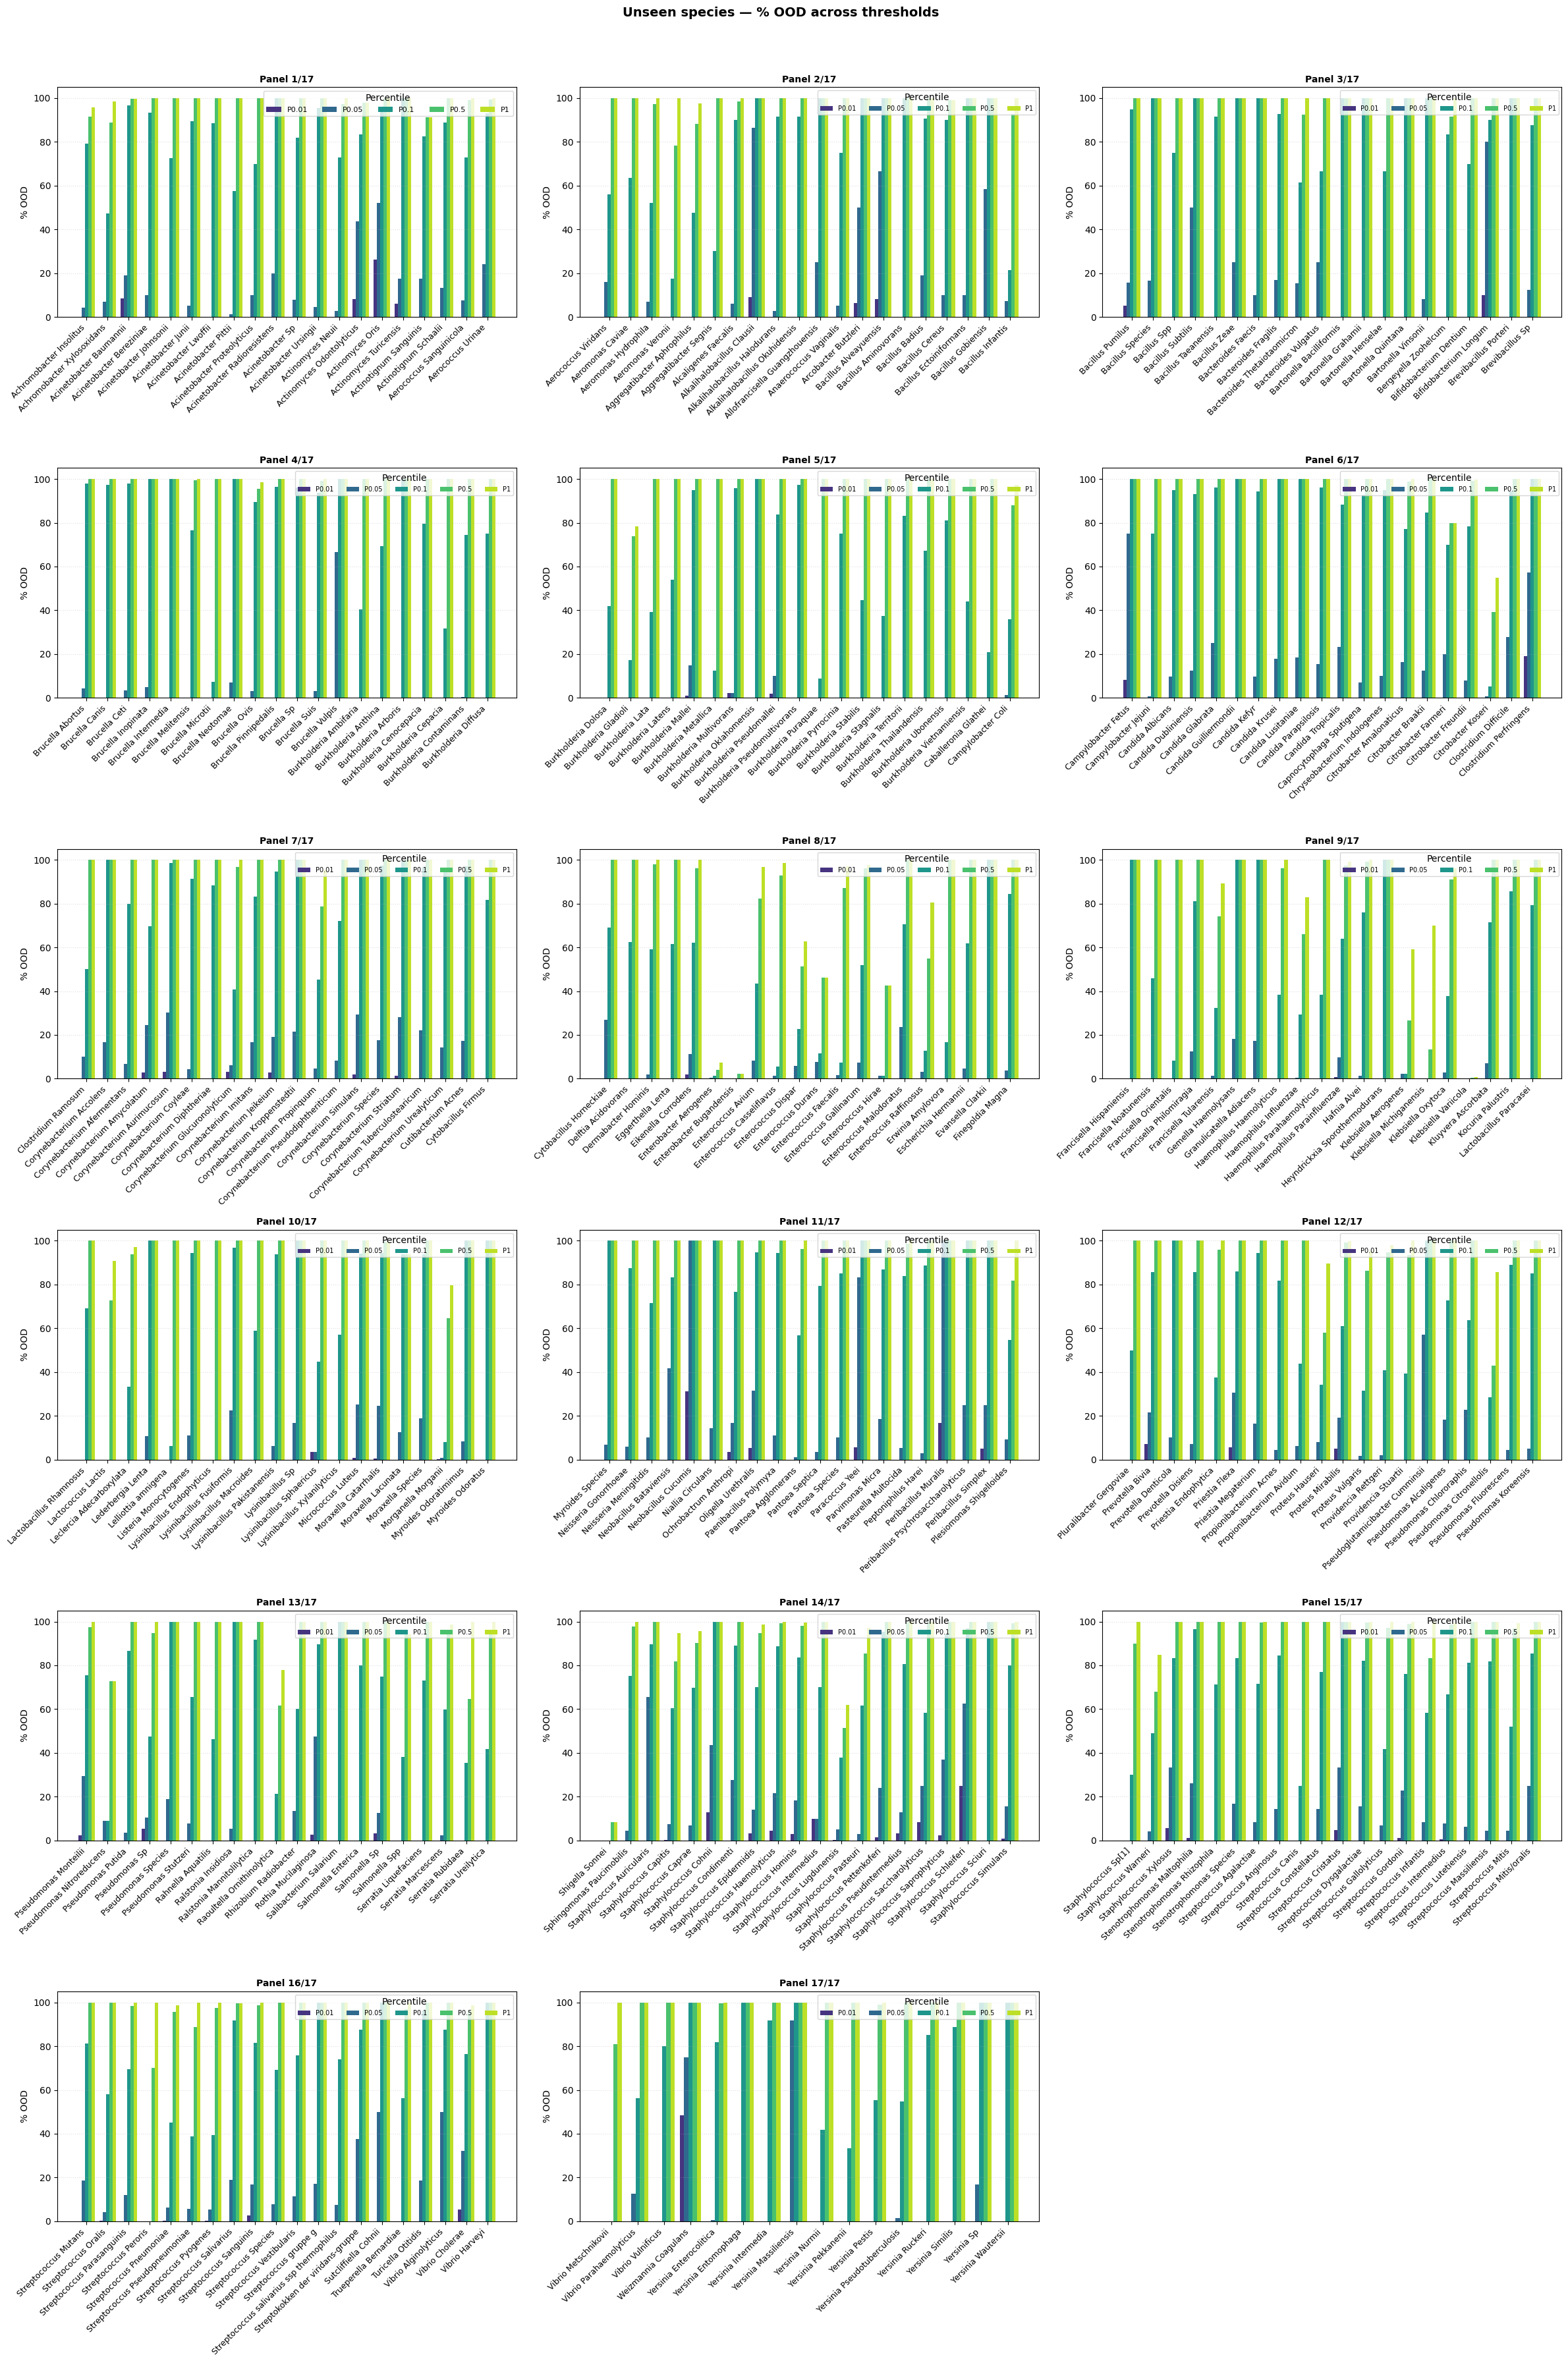

In [93]:
MIN_N = 10

df_unseen = pd.read_csv(OUTPUT_DIR / "unseen_species_ood_per_species_by_source.csv")

# agregar por especie (sumando n y promediando pct_ood ponderado por n de cada fuente)
agg_rows = []
pct_cols = [c for c in df_unseen.columns if c.startswith("P")]
for sp, group in df_unseen.groupby("species"):
    row = {"species": sp, "n": group["n"].sum()}
    for col in pct_cols:
        row[col] = (group["n"] * group[col]).sum() / group["n"].sum()
    agg_rows.append(row)
df_unseen = pd.DataFrame(agg_rows)
df_unseen = df_unseen[df_unseen["n"] >= MIN_N].copy()
print(f"Especies con n>={MIN_N}: {len(df_unseen)}")
df_unseen = df_unseen.sort_values("species", ascending=True).reset_index(drop=True)

############################################################
# BARPLOT — vertical, varias filas x columnas, orden alfabético
############################################################
n_species = len(df_unseen)
n_per_panel = 20
n_panels = int(np.ceil(n_species / n_per_panel))
n_cols = 3
n_rows = int(np.ceil(n_panels / n_cols))

colors_pct = plt.cm.viridis(np.linspace(0.15, 0.9, len(SWEEP_PERCENTILES)))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 6 * n_rows))
axes = np.array(axes).reshape(-1)

for panel_i in range(n_panels):
    start = panel_i * n_per_panel
    end = min(start + n_per_panel, n_species)
    sub = df_unseen.iloc[start:end]

    x = np.arange(len(sub))
    width = 0.8 / len(SWEEP_PERCENTILES)

    ax = axes[panel_i]
    for i, p in enumerate(SWEEP_PERCENTILES):
        col = f"P{p}"
        vals = sub[col].values
        ax.bar(x + i * width, vals, width, color=colors_pct[i], label=f"P{p}")

    ax.set_xticks(x + width * (len(SWEEP_PERCENTILES) - 1) / 2)
    ax.set_xticklabels(sub["species"].str.replace("_", " "), fontsize=9, rotation=45, ha="right")
    ax.set_ylim(0, 105)
    ax.set_ylabel("% OOD")
    ax.set_title(f"Panel {panel_i+1}/{n_panels}", fontsize=10, fontweight="bold")
    ax.legend(title="Percentile", fontsize=7, loc="upper right", ncol=len(SWEEP_PERCENTILES))
    ax.grid(True, axis="y", linestyle=":", alpha=0.4)

    fig_p, ax_p = plt.subplots(figsize=(16, 6.5))
    for i, p in enumerate(SWEEP_PERCENTILES):
        col = f"P{p}"
        vals = sub[col].values
        ax_p.bar(x + i * width, vals, width, color=colors_pct[i], label=f"P{p}")

    ax_p.set_xticks(x + width * (len(SWEEP_PERCENTILES) - 1) / 2)
    ax_p.set_xticklabels(sub["species"].str.replace("_", " "), fontsize=9, rotation=45, ha="right")
    ax_p.set_ylim(0, 105)
    ax_p.set_ylabel("% OOD")
    ax_p.set_title(f"Unseen species — panel {panel_i+1}/{n_panels} (n≥{MIN_N})", fontsize=11, fontweight="bold", pad=15)
    ax_p.legend(title="Percentile", fontsize=8, loc="upper right")
    ax_p.grid(True, axis="y", linestyle=":", alpha=0.4)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.close(fig_p)

for j in range(n_panels, len(axes)):
    axes[j].axis("off")

axes[0].legend(title="Percentile", fontsize=8, loc="upper right", ncol=len(SWEEP_PERCENTILES))
fig.suptitle("Unseen species — % OOD across thresholds", fontsize=14, fontweight="bold", y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [70]:
df_cercanas = df_unseen[(df_unseen["n"] >= 30) & (df_unseen["P1"] < 80)].sort_values("P1")
print(df_cercanas[["species", "n", "P0.01", "P0.05", "P0.1", "P0.5", "P1"]].to_string(index=False))

                   species    n    P0.01    P0.05      P0.1      P0.5        P1
      Klebsiella_Variicola  664 0.000000 0.000000  0.000000  0.271988  0.725301
  Enterobacter_Bugandensis   48 0.000000 0.000000  0.000000  2.100000  2.100000
    Enterobacter_Aerogenes  433 0.200000 0.500000  1.400000  3.900000  7.200000
        Enterococcus_Hirae   73 0.000000 1.358904  1.358904 42.465753 42.465753
        Citrobacter_Koseri 1767 0.000000 0.676684  5.304244 39.077419 54.785682
      Klebsiella_Aerogenes  678 0.000000 2.352212  2.352212 26.535841 59.278319
Staphylococcus_Lugdunensis  950 0.217684 4.924737 37.986105 51.261474 61.891368
       Enterococcus_Dispar   35 0.000000 5.751429 22.817143 51.442857 62.851429
  Klebsiella_Michiganensis   30 0.000000 0.000000  0.000000 13.300000 70.000000
Raoultella_Ornithinolytica   99 0.000000 0.000000 21.236364 61.592929 77.747475
       Morganella_Morganii 1523 0.191661 0.792515  8.023572 64.554301 79.507288


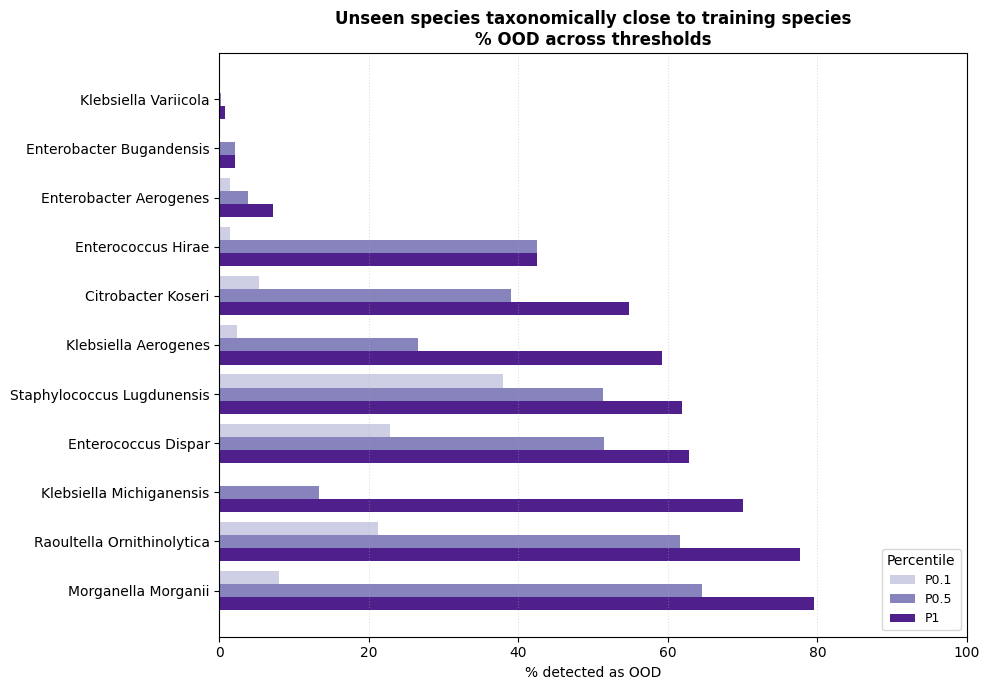

In [71]:
close_species = [
    "Klebsiella_Variicola", "Enterobacter_Bugandensis", "Enterobacter_Aerogenes",
    "Enterococcus_Hirae", "Citrobacter_Koseri", "Klebsiella_Aerogenes",
    "Staphylococcus_Lugdunensis", "Enterococcus_Dispar", "Klebsiella_Michiganensis",
    "Raoultella_Ornithinolytica", "Morganella_Morganii",
]

df_close = df_unseen[df_unseen["species"].isin(close_species)].copy()
df_close = df_close.set_index("species").loc[close_species]  
df_close.index = [s.replace("_", " ") for s in df_close.index]

pct_cols = [f"P{p}" for p in SWEEP_PERCENTILES]

############################################################
# BARPLOT — especies taxonómicamente cercanas, horizontal
############################################################
fig, ax = plt.subplots(figsize=(10, 7))

y = np.arange(len(df_close))
height = 0.8 / len(pct_cols)
colors = plt.cm.Purples(np.linspace(0.3, 0.9, len(pct_cols)))

for i, col in enumerate(pct_cols):
    ax.barh(y + i * height, df_close[col].values, height, color=colors[i], label=col)

ax.set_yticks(y + height * (len(pct_cols) - 1) / 2)
ax.set_yticklabels(df_close.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("% detected as OOD")
ax.set_xlim(0, 100)
ax.set_title("Unseen species taxonomically close to training species\n% OOD across thresholds",
             fontsize=12, fontweight="bold")
ax.legend(title="Percentile", fontsize=9, loc="lower right")
ax.grid(True, axis="x", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

Por qué estas especies son taxonómicamente próximas

**Klebsiella variicola, K. aerogenes y K. michiganensis** pertenecen al mismo género que *K. pneumoniae*, una de las especies de entrenamiento. *K. variicola* durante años fue clasificada erróneamente como *K. pneumoniae* en laboratorios que usaban métodos bioquímicos convencionales, y solo la secuenciación genómica permitió separarlas con fiabilidad. Su perfil proteico dominante por MALDI-TOF es prácticamente indistinguible del de *K. pneumoniae*, lo que explica que el modelo apenas la distinga incluso en el percentil más estricto del barrido (0,7%).

**Enterobacter aerogenes y E. bugandensis** comparten género con *Enterobacter cloacae complex*, otra especie del entrenamiento. *E. aerogenes* fue de hecho reclasificada en 2017 como *Klebsiella aerogenes* por su cercanía genómica con ese género, lo que ilustra lo borrosa que es la frontera taxonómica en este grupo — y por qué tanto las variantes de *Klebsiella* como las de *Enterobacter* aparecen agrupadas en la zona de menor detectabilidad.

**Citrobacter koseri, Raoultella ornithinolytica y Morganella morganii** son géneros distintos pero pertenecen a la misma familia, *Enterobacteriaceae*, junto con *Klebsiella* y *Enterobacter*. Comparten una pared celular y una composición proteica de membrana similares, lo que produce espectros MALDI-TOF con picos solapados en regiones equivalentes de masa/carga. Es coherente que se sitúen en una zona intermedia de detectabilidad: más distinguibles que las especies del mismo género, pero todavía menos que un organismo de otra familia bacteriana completamente distinta.

**Enterococcus hirae y E. dispar** son del mismo género que *Enterococcus faecium*. Los enterococos en general tienen perfiles MALDI-TOF muy conservados dentro del género, ya que comparten gran parte de su maquinaria ribosomal y de pared celular grampositiva.

**Staphylococcus lugdunensis** es un estafilococo coagulasa-negativo, un grupo conocido por solapar espectralmente con *S. aureus* (que sí está en el entrenamiento) más que con otras bacterias grampositivas, debido a la similitud de su envoltura celular.

En conjunto, el patrón observado no es ruido del modelo: refleja que el espacio latente aprendido por la red organiza las especies según su similitud espectral real, la cual a su vez está gobernada por relaciones evolutivas y estructurales genuinas. Cuanto más cercano es el parentesco taxonómico —mismo género primero, misma familia después— más difícil resulta para el detector de novedad distinguir la especie nueva de las que ya conoce, lo cual es exactamente el comportamiento que cabría esperar de un sistema que captura información biológica real en lugar de memorizar arbitrariamente las clases vistas durante el entrenamiento.

## Reconstruction error

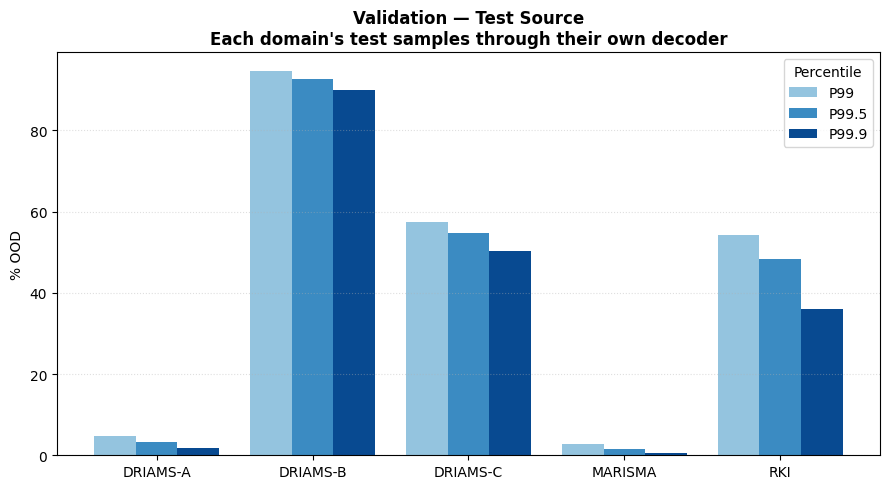

In [ ]:
OUTPUT_DIR = Path("/export/usuarios01/agnavarr/MALDIAlign/experiments/novelty_detection/reconstruction/20260622_084428")
SWEEP_PERCENTILES = [99, 99.5, 99.9]

############################################################
# PLOT 1 — VALIDACIÓN TEST SOURCE — BARPLOT
############################################################
df_val = pd.read_csv(OUTPUT_DIR / "sweep_validation_test_source_all_percentiles.csv", index_col="domain")

# las columnas vienen como strings tipo "4.8%" — convertir a float
for col in df_val.columns:
    df_val[col] = df_val[col].str.replace("%", "").astype(float)

fig, ax = plt.subplots(figsize=(9, 5))

domains = df_val.index.tolist()
x = np.arange(len(domains))
width = 0.8 / len(SWEEP_PERCENTILES)
colors_pct = plt.cm.Blues(np.linspace(0.4, 0.9, len(SWEEP_PERCENTILES)))

for i, p in enumerate(SWEEP_PERCENTILES):
    col = f"P{p}"
    vals = df_val[col].values
    ax.bar(x + i * width, vals, width, color=colors_pct[i], label=f"P{p}")

ax.set_xticks(x + width * (len(SWEEP_PERCENTILES) - 1) / 2)
ax.set_xticklabels([d.replace("DRIAMS_", "DRIAMS-") for d in domains], rotation=0)
ax.set_ylabel("% OOD")
ax.set_title("Validation — Test Source\nEach domain's test samples through their own decoder",
             fontsize=12, fontweight="bold")
ax.legend(title="Percentile")
ax.grid(True, axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

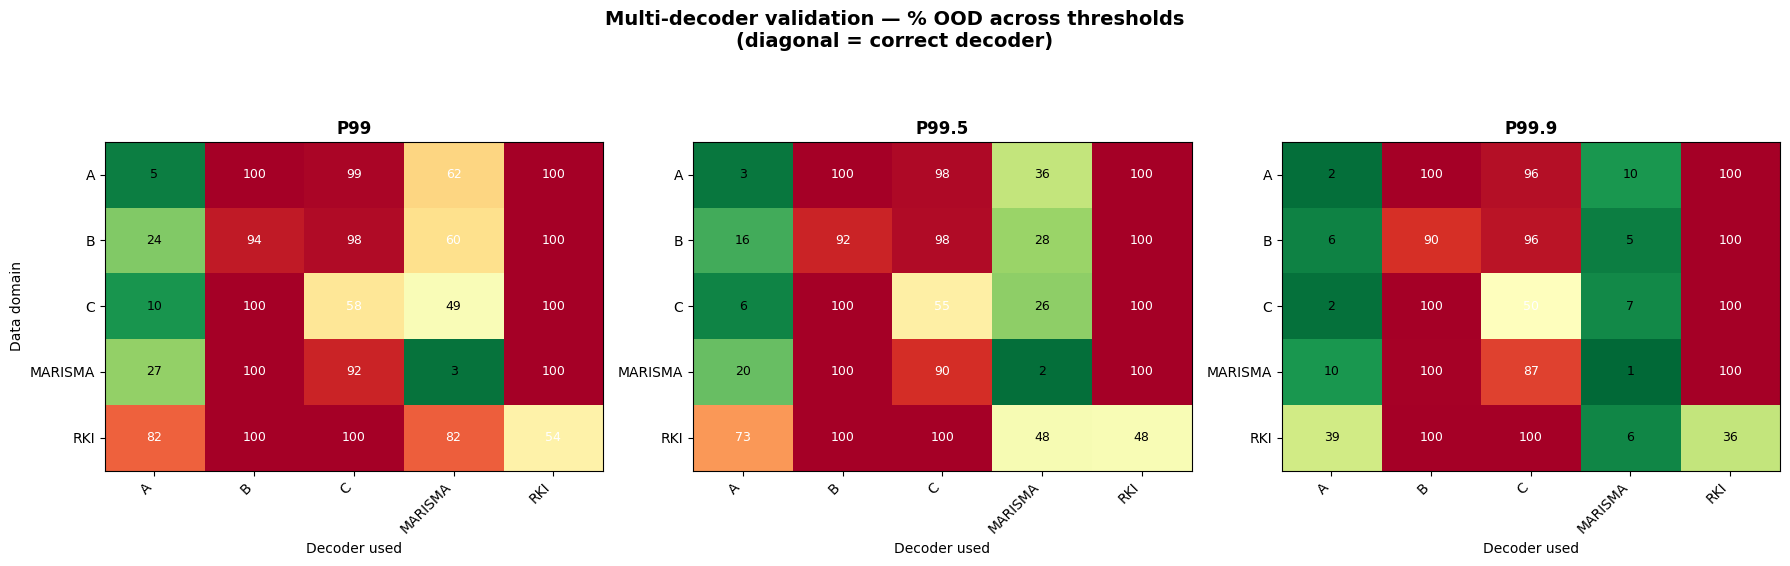

In [ ]:
############################################################
# PLOT 2 — MULTI-DECODER VALIDATION
############################################################
fig, axes = plt.subplots(1, len(SWEEP_PERCENTILES), figsize=(6 * len(SWEEP_PERCENTILES), 5.5))

for ax, p in zip(axes, SWEEP_PERCENTILES):
    fname = OUTPUT_DIR / f"sweep_cross_domain_p{str(p).replace('.','')}.csv"
    df_cross = pd.read_csv(fname, index_col=0)
    vals = df_cross.values.astype(float)

    im = ax.imshow(vals, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=100)
    ax.set_xticks(range(len(df_cross.columns)))
    ax.set_xticklabels([c.replace("DRIAMS_", "") for c in df_cross.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(df_cross.index)))
    ax.set_yticklabels([r.replace("DRIAMS_", "") for r in df_cross.index])
    ax.set_xlabel("Decoder used")
    if p == SWEEP_PERCENTILES[0]:
        ax.set_ylabel("Data domain")
    ax.set_title(f"P{p}", fontsize=12, fontweight="bold")

    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            val = vals[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=9,
                        color="white" if val > 50 else "black")

fig.suptitle("Multi-decoder validation — % OOD across thresholds\n(diagonal = correct decoder)",fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

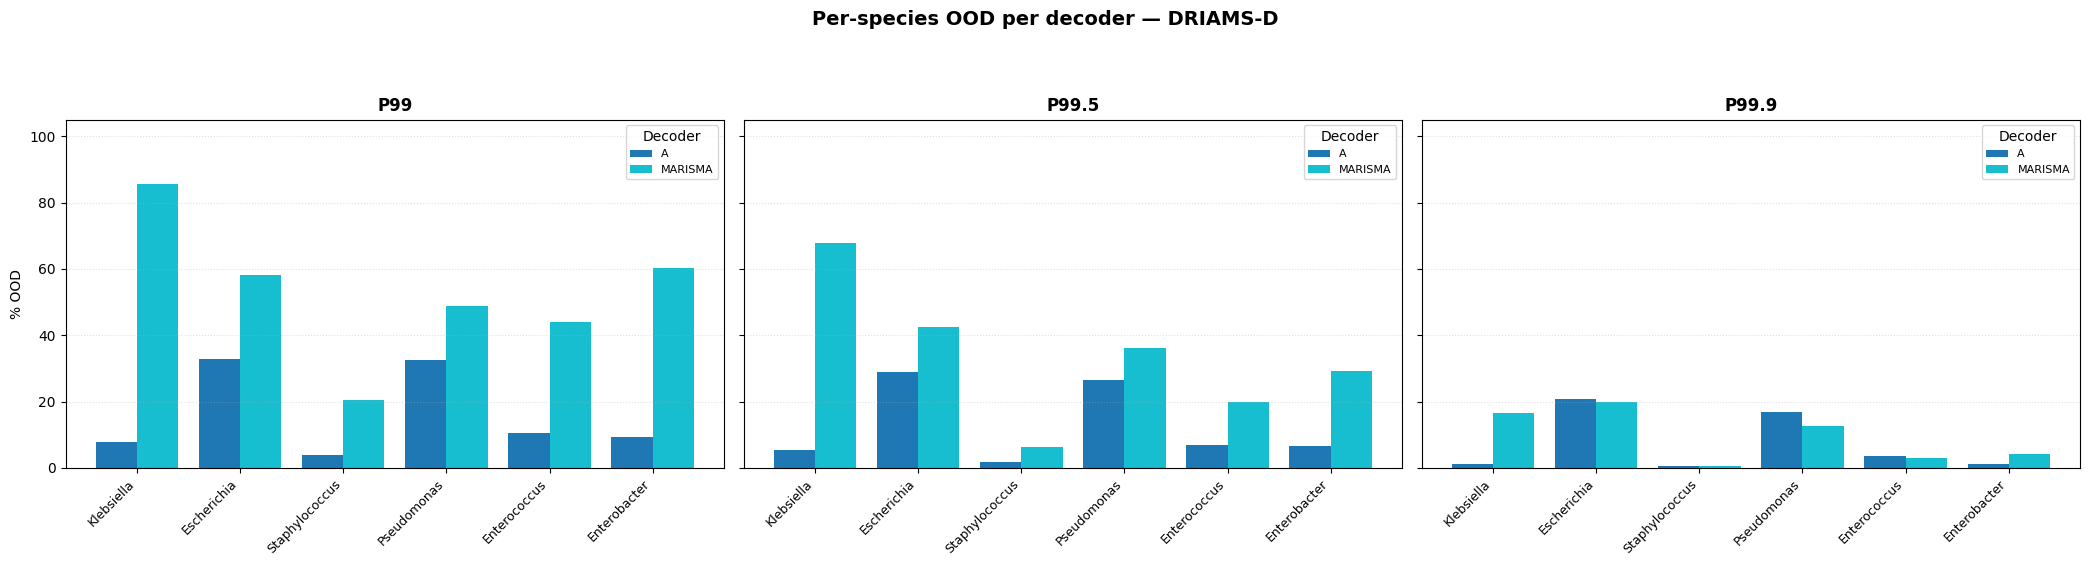

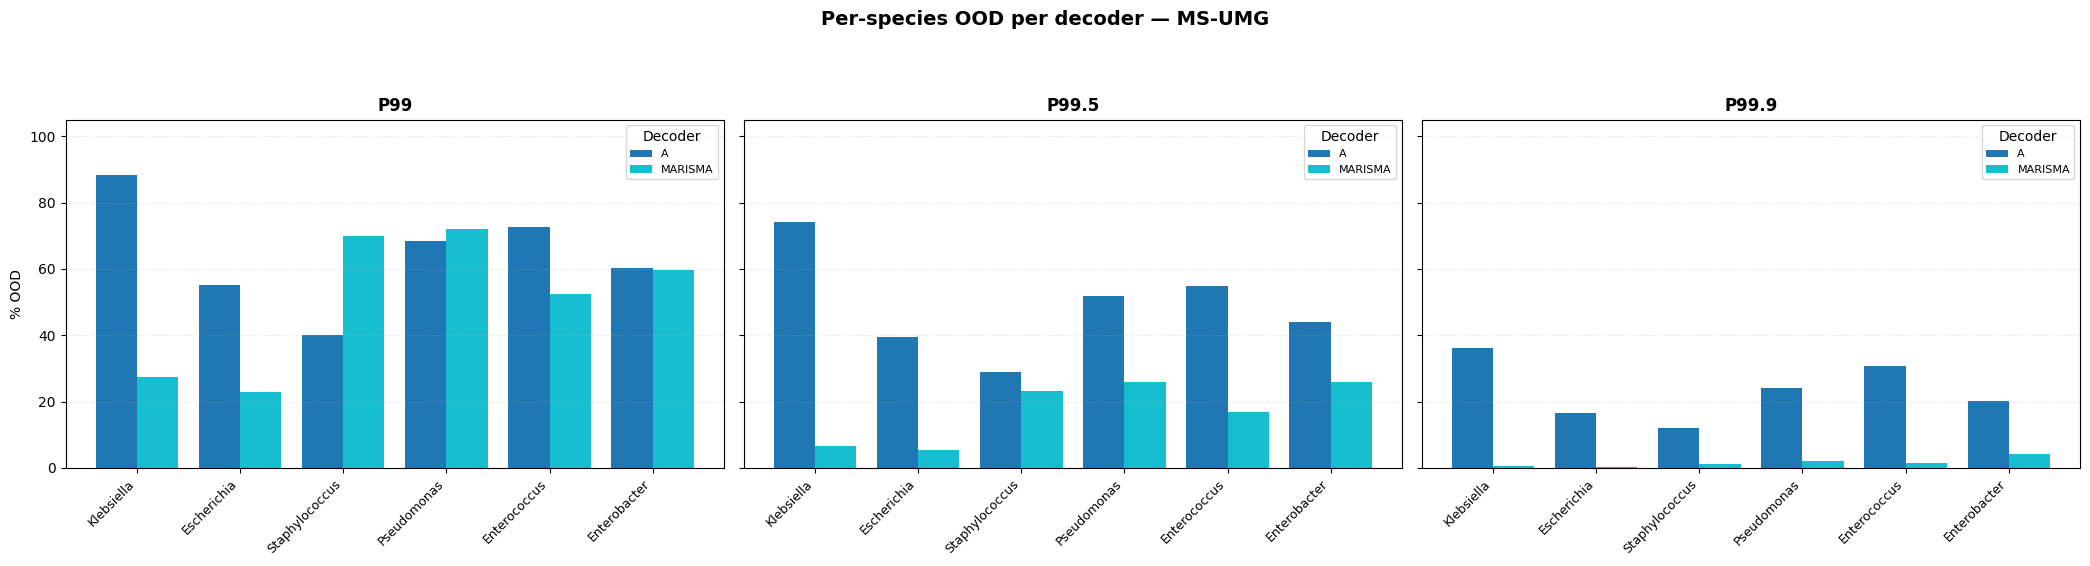

In [94]:
OUTPUT_DIR = Path("/export/usuarios01/agnavarr/MALDIAlign/experiments/novelty_detection/reconstruction/20260622_084428")
SWEEP_PERCENTILES = [99, 99.5, 99.9]
DECODER_FILE_NAMES = {"A": "DRIAMS_A", "MARISMA": "MARISMA"}

############################################################
# PLOT 3 — PER-SPECIES OOD PER DECODER
############################################################
for ds_name in ["DRIAMS_D", "MS_UMG"]:
    fig, axes = plt.subplots(1, len(SWEEP_PERCENTILES), figsize=(7 * len(SWEEP_PERCENTILES), 5.5), sharey=True)

    dfs_by_decoder = {}
    for k, file_suffix in DECODER_FILE_NAMES.items():
        fname = OUTPUT_DIR / f"sweep_per_species_{ds_name}_dec_{file_suffix}.csv"
        df = pd.read_csv(fname, index_col="species")
        for col in df.columns:
            if col == "n":
                continue
            df[col] = df[col].astype(str).str.replace("%", "").astype(float)
        dfs_by_decoder[k] = df

    species_list = dfs_by_decoder["A"].index.tolist()
    colors_dec = plt.cm.tab10(np.linspace(0, 0.9, len(DECODER_FILE_NAMES)))

    for ax, p in zip(axes, SWEEP_PERCENTILES):
        x = np.arange(len(species_list))
        width = 0.8 / len(DECODER_FILE_NAMES)

        for i, (k, color) in enumerate(zip(DECODER_FILE_NAMES.keys(), colors_dec)):
            vals = dfs_by_decoder[k][f"P{p}"].values
            ax.bar(x + i * width, vals, width, color=color, label=k)

        ax.set_xticks(x + width * (len(DECODER_FILE_NAMES) - 1) / 2)
        ax.set_xticklabels(species_list, rotation=45, ha="right", fontsize=9)
        ax.set_ylim(0, 105)
        ax.set_title(f"P{p}", fontsize=12, fontweight="bold")
        ax.grid(True, axis="y", linestyle=":", alpha=0.4)
        ax.legend(title="Decoder", fontsize=8, loc="upper right")

    axes[0].set_ylabel("% OOD")
    fig.suptitle(f"Per-species OOD per decoder — {ds_name.replace('_', '-')}",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

Especies con n>=10: 336


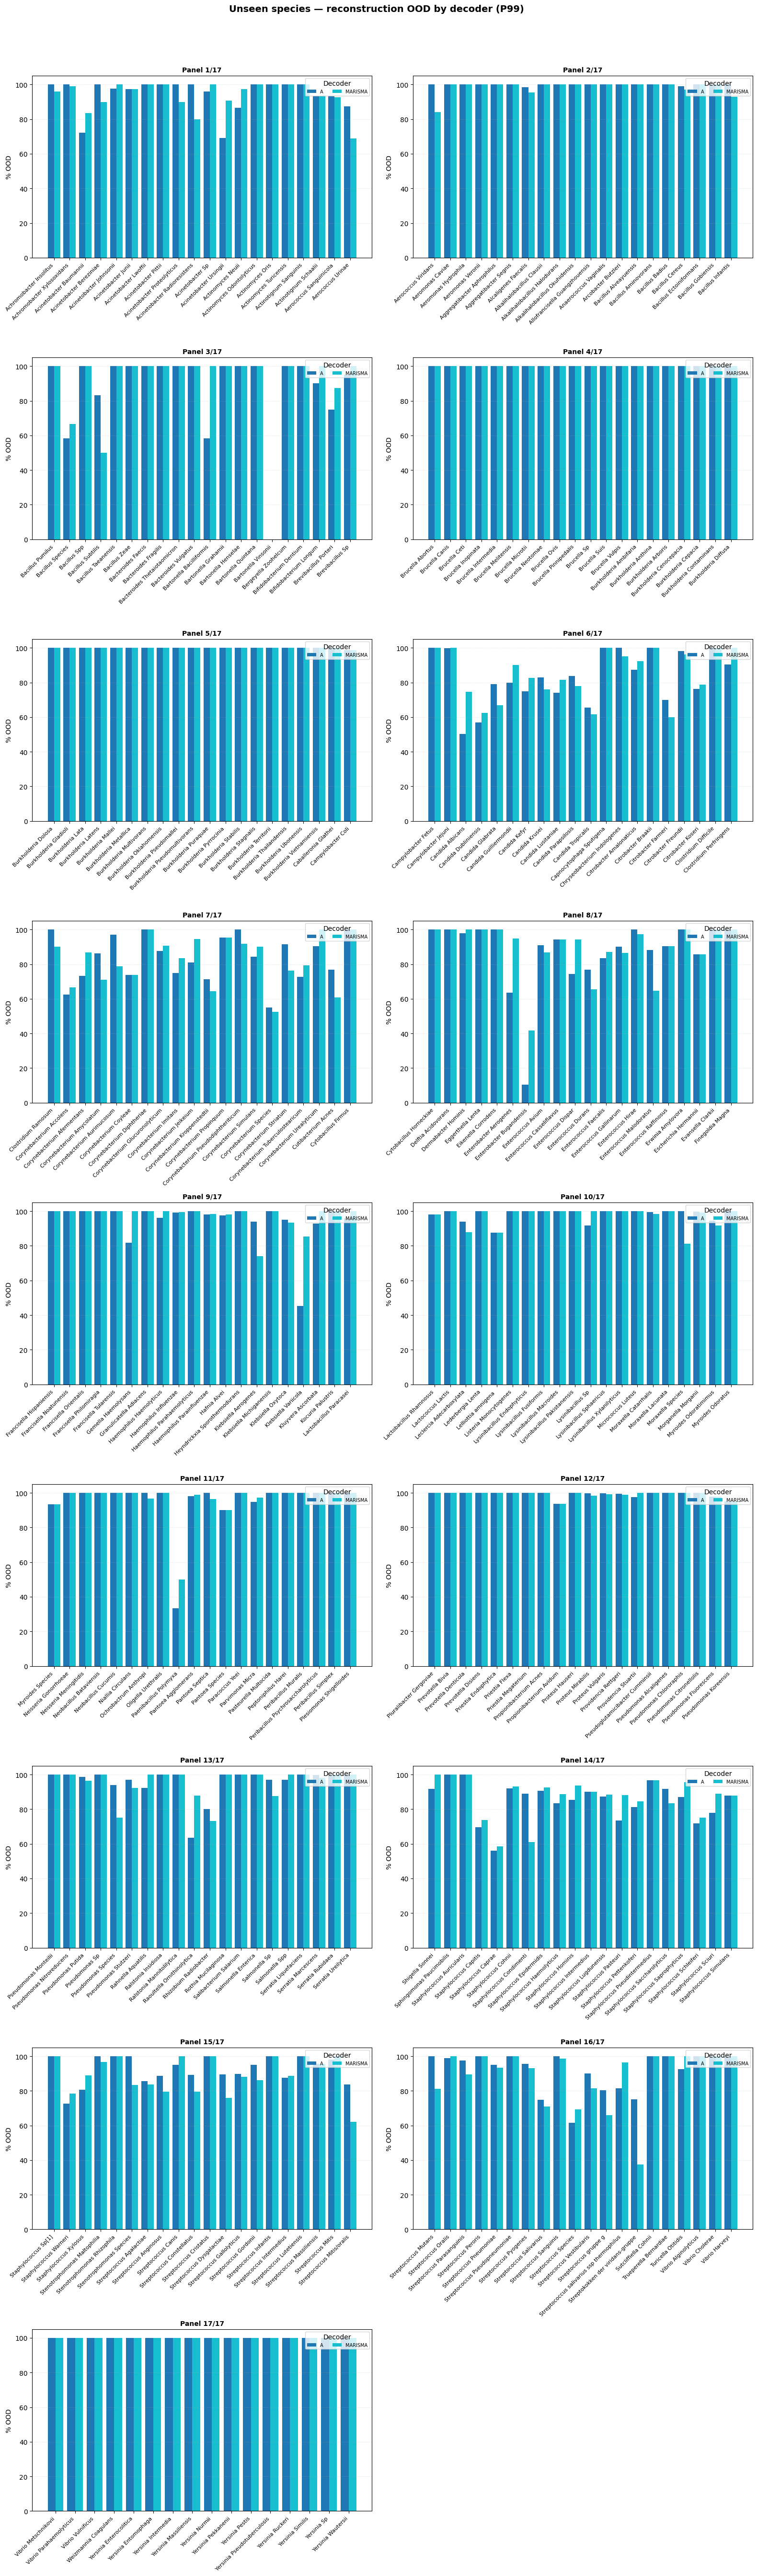

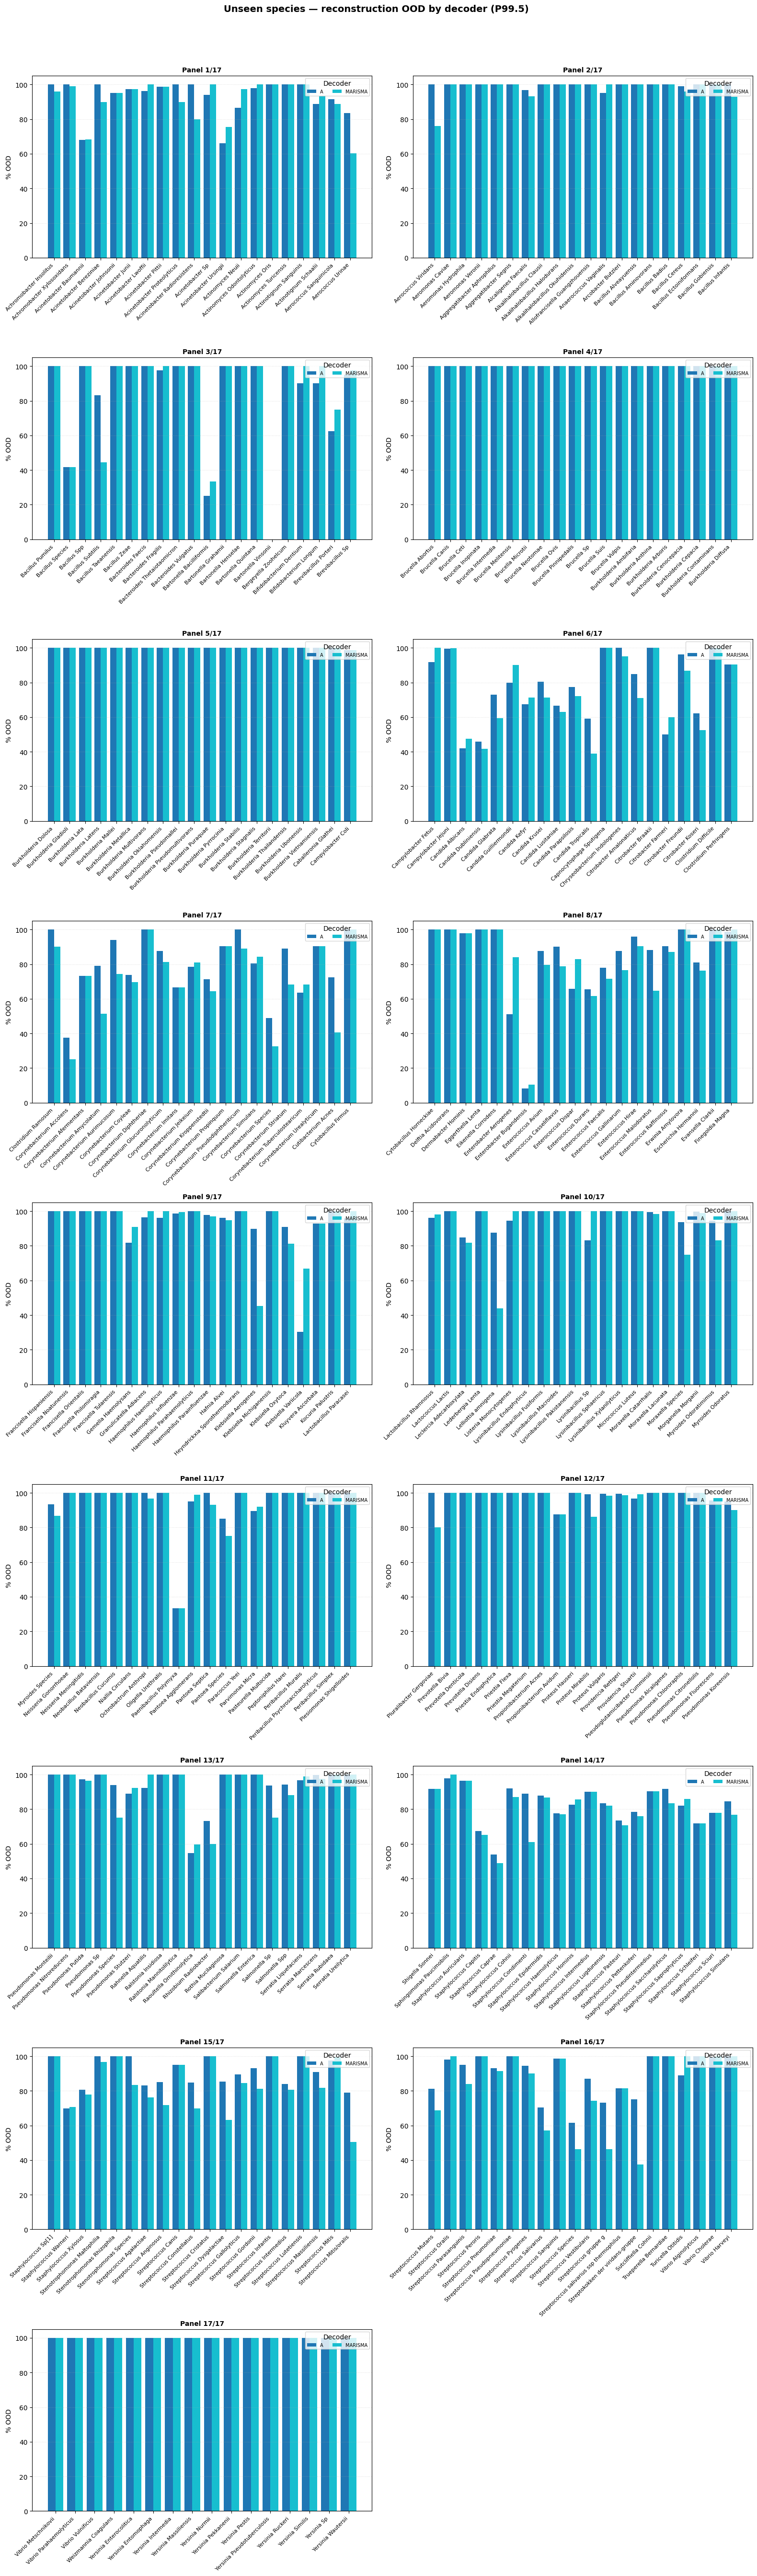

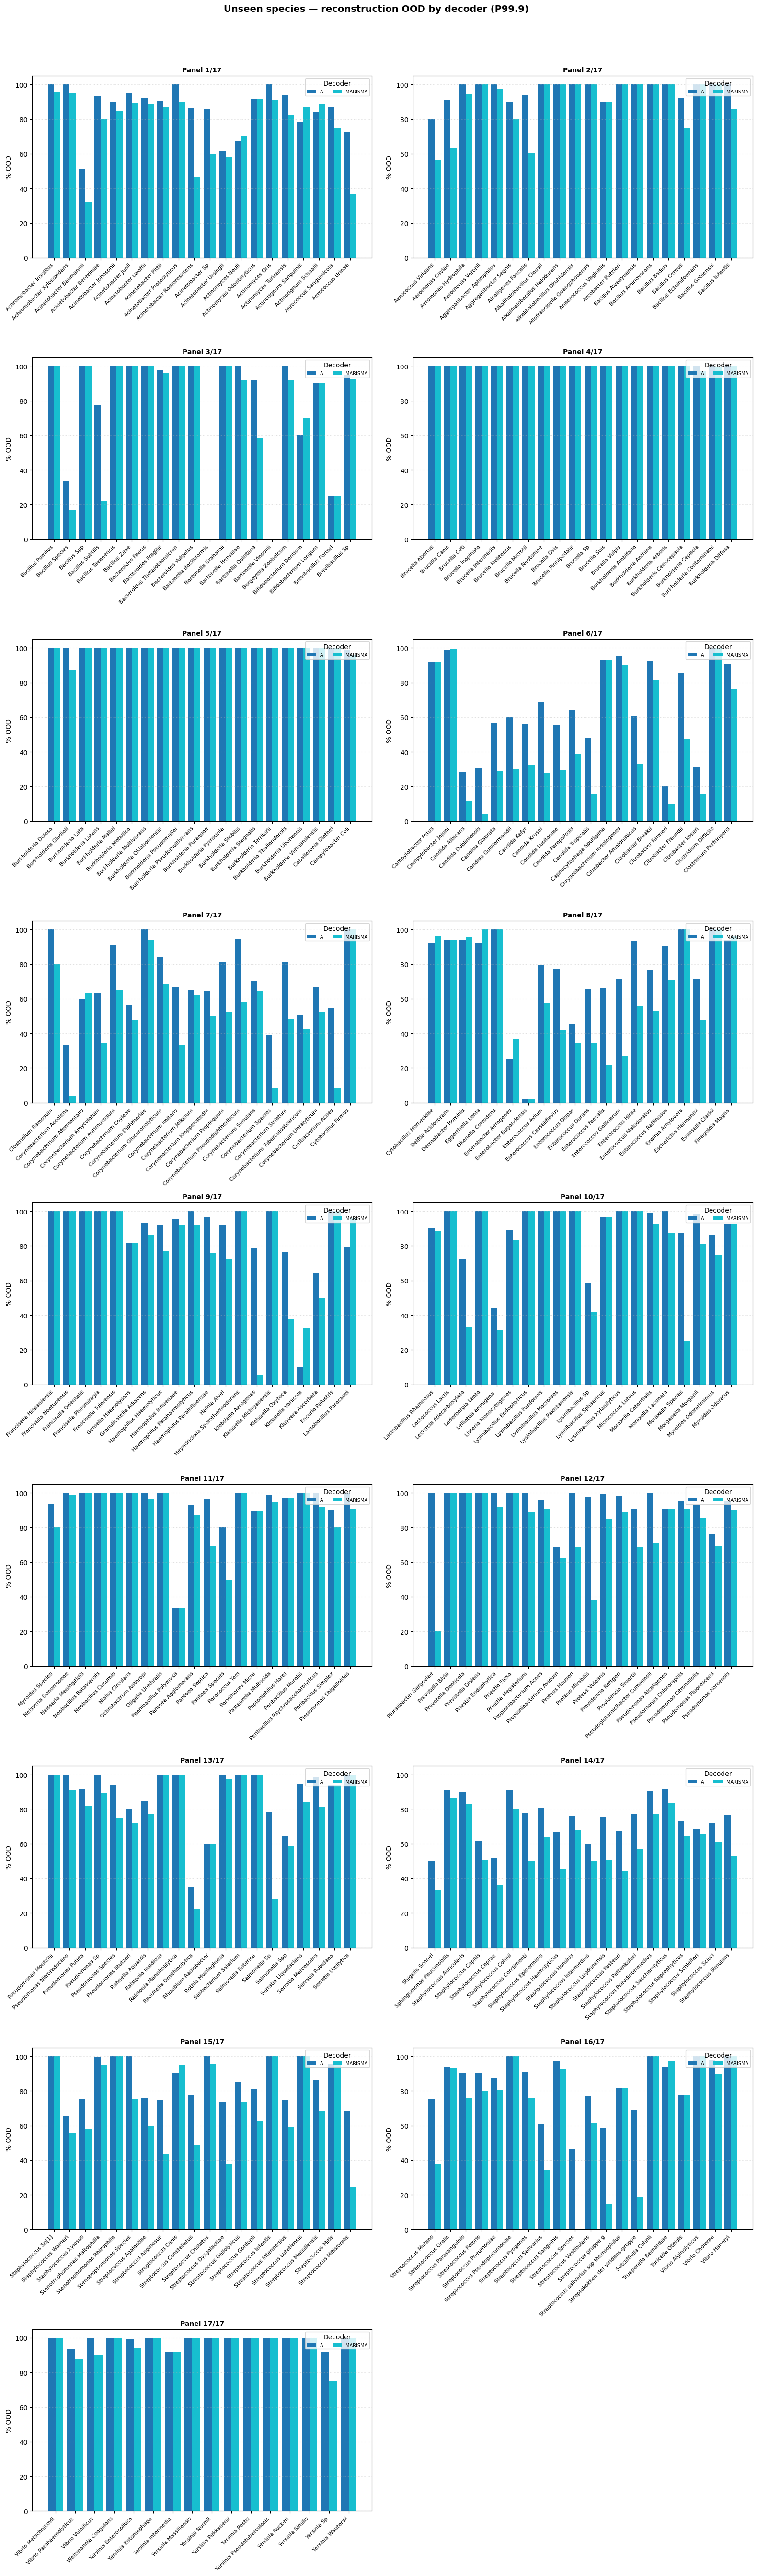

In [96]:
SWEEP_PERCENTILES = [99, 99.5, 99.9]
DECODER_FILE_NAMES = {"A": "DRIAMS_A", "MARISMA": "MARISMA",}
MIN_N = 10

############################################################
# LEER Y AGREGAR (ponderado por n) sobre las 4 fuentes
############################################################
dfs_by_decoder = {}
for k, file_suffix in DECODER_FILE_NAMES.items():
    fname = OUTPUT_DIR / f"unseen_species_ood_per_species_by_source_dec_{file_suffix}.csv"
    df = pd.read_csv(fname)

    pct_cols = [c for c in df.columns if c.startswith("P")]
    agg_rows = []
    for sp, group in df.groupby("species"):
        row = {"species": sp, "n": group["n"].sum()}
        for col in pct_cols:
            row[col] = (group["n"] * group[col]).sum() / group["n"].sum()
        agg_rows.append(row)
    dfs_by_decoder[k] = pd.DataFrame(agg_rows).set_index("species")

# filtrar por n mínimo (usando el decoder A como referencia de n, es igual en todos)
valid_species = dfs_by_decoder["A"][dfs_by_decoder["A"]["n"] >= MIN_N].index
for k in dfs_by_decoder:
    dfs_by_decoder[k] = dfs_by_decoder[k].loc[valid_species]

print(f"Especies con n>={MIN_N}: {len(valid_species)}")

# orden alfabético
species_list = sorted(valid_species)
for k in dfs_by_decoder:
    dfs_by_decoder[k] = dfs_by_decoder[k].loc[species_list]

############################################################
# BARPLOT — varias filas x columnas, 5 decoders agrupados, un percentil por figura
############################################################
n_species = len(species_list)
n_per_panel = 20
n_panels = int(np.ceil(n_species / n_per_panel))
n_cols = 2
n_rows = int(np.ceil(n_panels / n_cols))

colors_dec = plt.cm.tab10(np.linspace(0, 0.9, len(DECODER_FILE_NAMES)))

for p in SWEEP_PERCENTILES:
    col = f"P{p}"

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 6 * n_rows))
    axes = np.array(axes).reshape(-1)

    for panel_i in range(n_panels):
        start = panel_i * n_per_panel
        end = min(start + n_per_panel, n_species)
        sub_species = species_list[start:end]

        ax = axes[panel_i]
        x = np.arange(len(sub_species))
        width = 0.8 / len(DECODER_FILE_NAMES)

        for i, (k, color) in enumerate(zip(DECODER_FILE_NAMES.keys(), colors_dec)):
            vals = dfs_by_decoder[k].loc[sub_species, col].values
            ax.bar(x + i * width, vals, width, color=color, label=k)

        ax.set_xticks(x + width * (len(DECODER_FILE_NAMES) - 1) / 2)
        ax.set_xticklabels([s.replace("_", " ") for s in sub_species], fontsize=8, rotation=45, ha="right")
        ax.set_ylim(0, 105)
        ax.set_ylabel("% OOD")
        ax.set_title(f"Panel {panel_i+1}/{n_panels}", fontsize=10, fontweight="bold")
        ax.legend(title="Decoder", fontsize=7, loc="upper right", ncol=len(DECODER_FILE_NAMES))
        ax.grid(True, axis="y", linestyle=":", alpha=0.4)

        # también guardar cada panel individual
        fig_p, ax_p = plt.subplots(figsize=(16, 6.5))
        for i, (k, color) in enumerate(zip(DECODER_FILE_NAMES.keys(), colors_dec)):
            vals = dfs_by_decoder[k].loc[sub_species, col].values
            ax_p.bar(x + i * width, vals, width, color=color, label=k)
        ax_p.set_xticks(x + width * (len(DECODER_FILE_NAMES) - 1) / 2)
        ax_p.set_xticklabels([s.replace("_", " ") for s in sub_species], fontsize=9, rotation=45, ha="right")
        ax_p.set_ylim(0, 105)
        ax_p.set_ylabel("% OOD")
        ax_p.set_title(f"Unseen species — {col} — panel {panel_i+1}/{n_panels} (n≥{MIN_N})", fontsize=11, fontweight="bold", pad=8)
        ax_p.legend(title="Decoder", fontsize=8, loc="upper right")
        ax_p.grid(True, axis="y", linestyle=":", alpha=0.4)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.close(fig_p)

    for j in range(n_panels, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Unseen species — reconstruction OOD by decoder ({col})", fontsize=14, fontweight="bold", y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()


## Combined detector

In [4]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path("/export/usuarios01/agnavarr/MALDIAlign/experiments/novelty_detection/combined/20260622_174852")

df_unseen = pd.read_csv(OUTPUT_DIR / "unseen_species_ood_by_criterion.csv")

# filtrar solo percentil = 1 y solo las columnas de GMM
df_gmm_p1 = df_unseen[df_unseen["percentile"] == 1][["species", "n_total", "GMM_n_ood", "GMM_n_indist", "GMM_pct_ood"]]
df_gmm_p1 = df_gmm_p1.sort_values("GMM_pct_ood")

print(df_gmm_p1.to_string(index=False))

                                  species  n_total  GMM_n_ood  GMM_n_indist  GMM_pct_ood
                     Klebsiella_Variicola      664          5           659          0.8
                 Enterobacter_Bugandensis       48          1            47          2.1
                   Enterobacter_Aerogenes      433         31           402          7.2
                          Shigella_Sonnei       12          1            11          8.3
                       Enterococcus_Hirae       73         31            42         42.5
                      Enterococcus_Durans       26         12            14         46.2
                       Citrobacter_Koseri     1767        968           799         54.8
                     Klebsiella_Aerogenes      678        402           276         59.3
               Staphylococcus_Lugdunensis      950        588           362         61.9
                      Enterococcus_Dispar       35         22            13         62.9
                 Kleb

In [8]:
# géneros de las especies de entrenamiento (TARGET_SPECIES)
TARGET_SPECIES = [
    "Klebsiella_Pneumoniae", "Escherichia_Coli", "Staphylococcus_Aureus",
    "Pseudomonas_Aeruginosa", "Enterococcus_Faecium", "Enterobacter_cloacae_complex",
]
train_genera = set(sp.split("_")[0] for sp in TARGET_SPECIES)
print(f"Géneros de entrenamiento: {train_genera}")

# extraer género de cada especie no vista
df_gmm_p1["genus"] = df_gmm_p1["species"].str.split("_").str[0]

# marcar si el género coincide con alguno de train
df_gmm_p1["same_genus_as_train"] = df_gmm_p1["genus"].isin(train_genera)

# dividir en dos tablas
df_same_genus = df_gmm_p1[df_gmm_p1["same_genus_as_train"]].sort_values("GMM_pct_ood")
df_diff_genus = df_gmm_p1[~df_gmm_p1["same_genus_as_train"]].sort_values("GMM_pct_ood")

print(f"\n===== MISMO GÉNERO QUE TRAIN (n={len(df_same_genus)}) =====")
print(df_same_genus.to_string(index=False))

print(f"\n===== GÉNERO DISTINTO A TRAIN (n={len(df_diff_genus)}) =====")
print(df_diff_genus.to_string(index=False))

# medias simples (por especie) y ponderadas (por muestra)
mean_simple_same = df_same_genus["GMM_pct_ood"].mean()
mean_weighted_same = 100 * df_same_genus["GMM_n_ood"].sum() / df_same_genus["n_total"].sum()

mean_simple_diff = df_diff_genus["GMM_pct_ood"].mean()
mean_weighted_diff = 100 * df_diff_genus["GMM_n_ood"].sum() / df_diff_genus["n_total"].sum()

print(f"\nResumen:")
print(f"  Mismo género    — n_species={len(df_same_genus)}  n_samples={df_same_genus['n_total'].sum()}")
print(f"                    media simple (por especie):    {mean_simple_same:.1f}%")
print(f"                    media ponderada (por muestra):  {mean_weighted_same:.1f}%")
print(f"  Género distinto — n_species={len(df_diff_genus)}  n_samples={df_diff_genus['n_total'].sum()}")
print(f"                    media simple (por especie):    {mean_simple_diff:.1f}%")
print(f"                    media ponderada (por muestra):  {mean_weighted_diff:.1f}%")

Géneros de entrenamiento: {'Escherichia', 'Enterococcus', 'Staphylococcus', 'Pseudomonas', 'Klebsiella', 'Enterobacter'}

===== MISMO GÉNERO QUE TRAIN (n=48) =====
                        species  n_total  GMM_n_ood  GMM_n_indist  GMM_pct_ood          genus  same_genus_as_train
           Klebsiella_Variicola      664          5           659          0.8     Klebsiella                 True
       Enterobacter_Bugandensis       48          1            47          2.1   Enterobacter                 True
         Enterobacter_Aerogenes      433         31           402          7.2   Enterobacter                 True
             Enterococcus_Hirae       73         31            42         42.5   Enterococcus                 True
            Enterococcus_Durans       26         12            14         46.2   Enterococcus                 True
           Klebsiella_Aerogenes      678        402           276         59.3     Klebsiella                 True
     Staphylococcus_Lugdunensis